# DE in CD4 T cells and by zones

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [1]:
from pathlib import Path
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import squidpy as sq

import pickle

import matplotlib as mpl
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['pdf.fonttype'] = 42

warnings.simplefilter(action='ignore', category=Warning)

## Local file info


In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis")

plot_out_dir = os.path.join(out_dir, 'plots')


In [3]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

# import DE functions from de_utils
from de_utils import filter_adata_expressed_in_n_cells, run_zone_DE_analysis

## Load adata

In [4]:
adata = sc.read_h5ad(os.path.join(out_dir,'adata_distance.h5ad'))

## Load palettes

In [5]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'rb') as f:
    zone_consol_palette_mapped = pickle.load(f)

## CD4 DE between zones

### Run DE tests

In [6]:
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv(os.path.join(BASE_OUTDIR, 'cell_labeling/ouputs_mouselung_hurskainen_ref_consolidate_labels_xenseg_HDM/cite_integration/cite_expressed_genes_by_annotation.csv'))
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
adata_cd4 = adata[adata.obs['label_coarse']=='CD4 T cell', :].copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection and use this list for heatmaps 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

Subset shape: (8502, 180) for celltype: CD4 act
not subsetting by cell type
removing genes by expression threshold:  0.01


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Unique DEGs before pval/lfc filter: 180
Unique DEGs after pval/lfc filter: 72


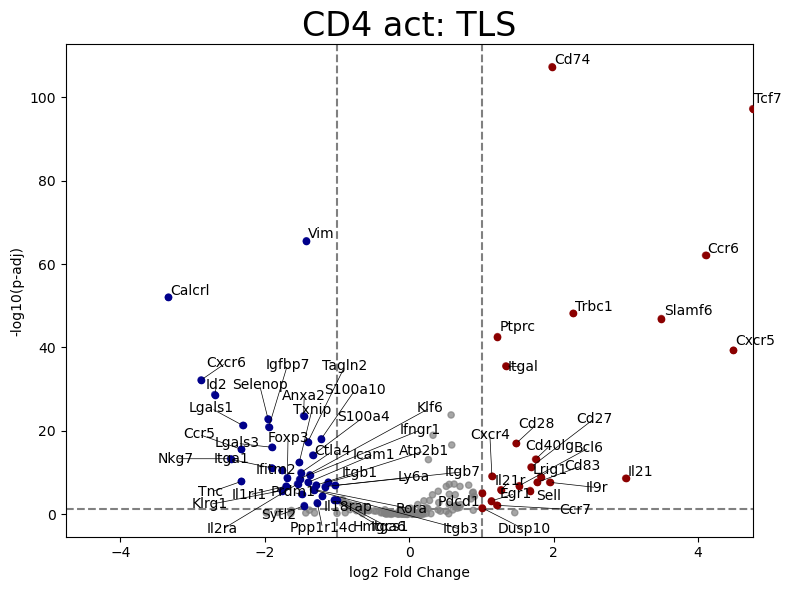

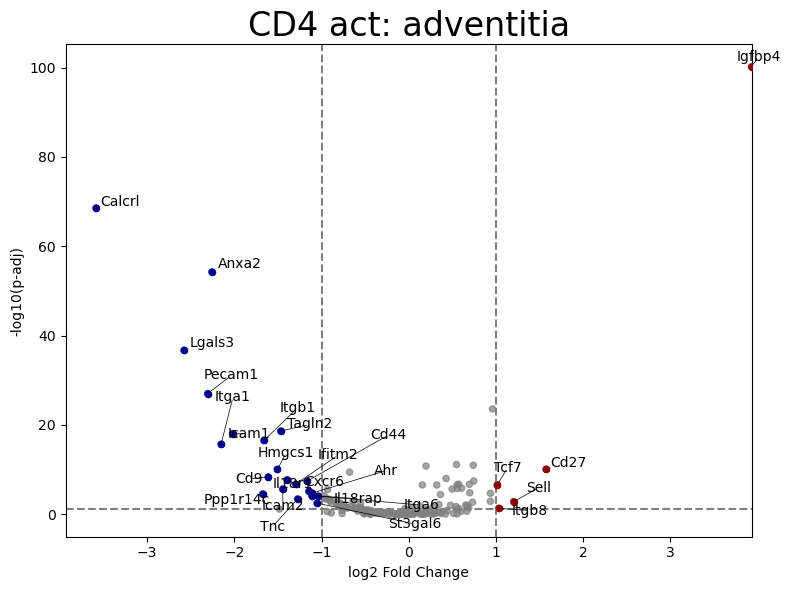

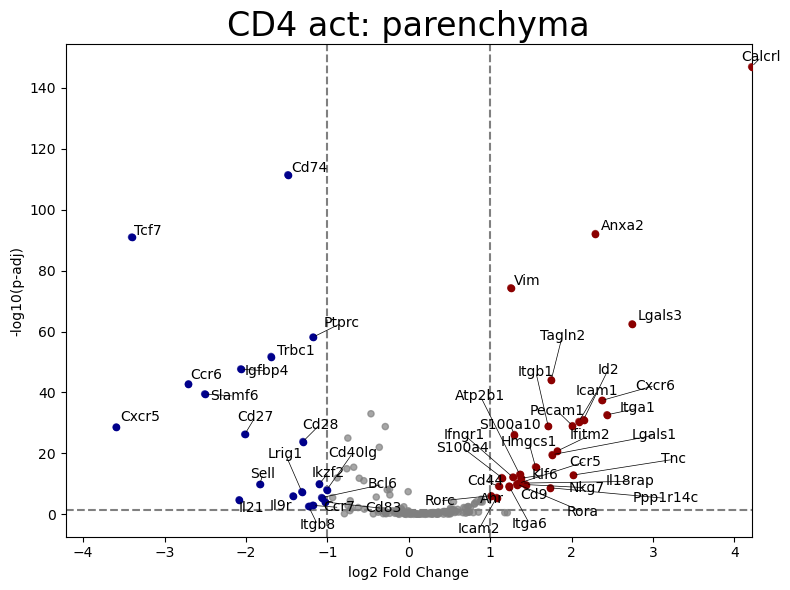

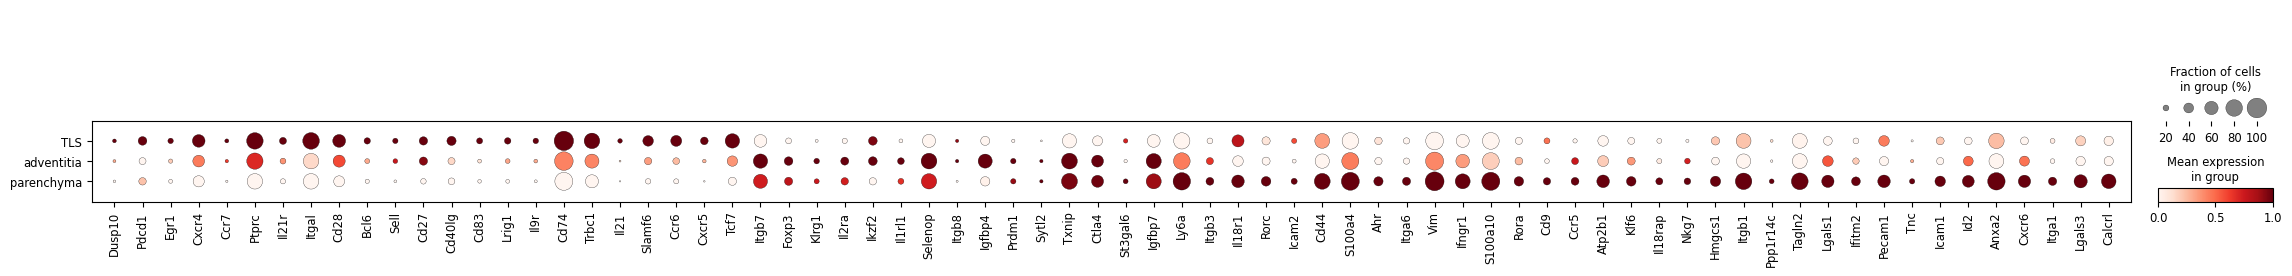

In [7]:
sample_label = 'HDM_day3'
zone_col = 'zone_consol'
zone_order=['TLS','adventitia', 'parenchyma'] 
    
adata_select = adata[adata.obs['sample_label']==sample_label, genes_cite_xen_filt]
adata_select = adata_select[adata_select.obs[zone_col].isin(zone_order),:]
    
df_DEG_cd4, df_DEG_cd4_filt = run_zone_DE_analysis(
    adata=adata_select,
    celltype='CD4 act',
    celltype_col = 'label_medium',
    zone_col = 'zone_consol',
    zone_order=['TLS','adventitia', 'parenchyma'], 
    reference_zone='rest',
    lfc_cutoff=1,
    pval_cutoff=0.05,
    dot_save_path =os.path.join(plot_out_dir, 'dotplot_cd4_zone_de.pdf')
)

## Ligand DE between zones
What ligands are different between zones?

In [9]:
# list of cellchat ligands that are contained in our panel
df_lr = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
ligands_panel = df_lr[df_lr['ligand'].isin(adata.var.index)]['ligand'].unique().tolist()
len(ligands_panel)


99

Subset shape: (321693, 99) - no celltype subsetting
not subsetting by cell type
removing genes by expression threshold:  0.01
Unique DEGs before pval/lfc filter: 75
Unique DEGs after pval/lfc filter: 69


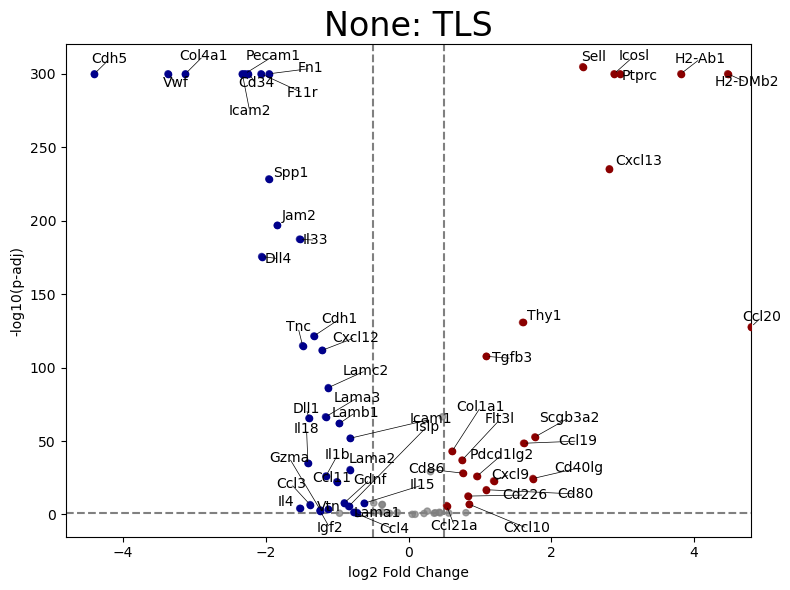

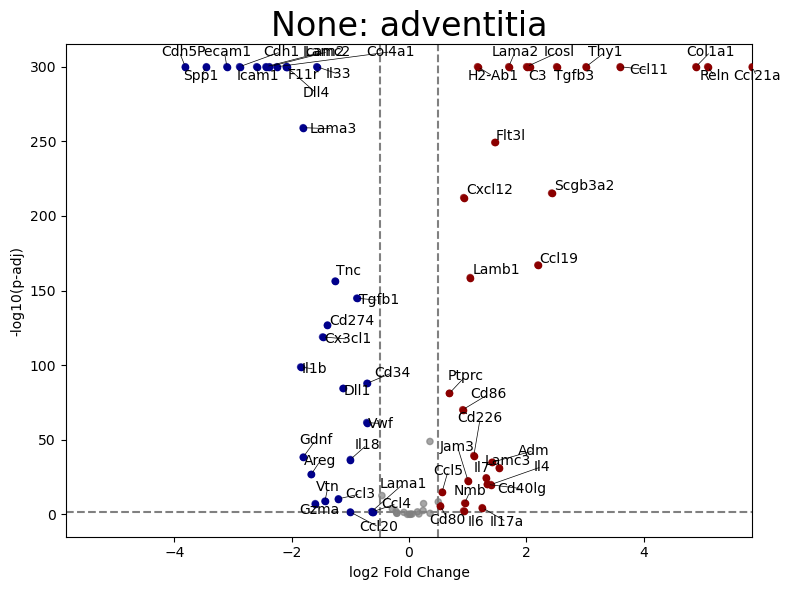

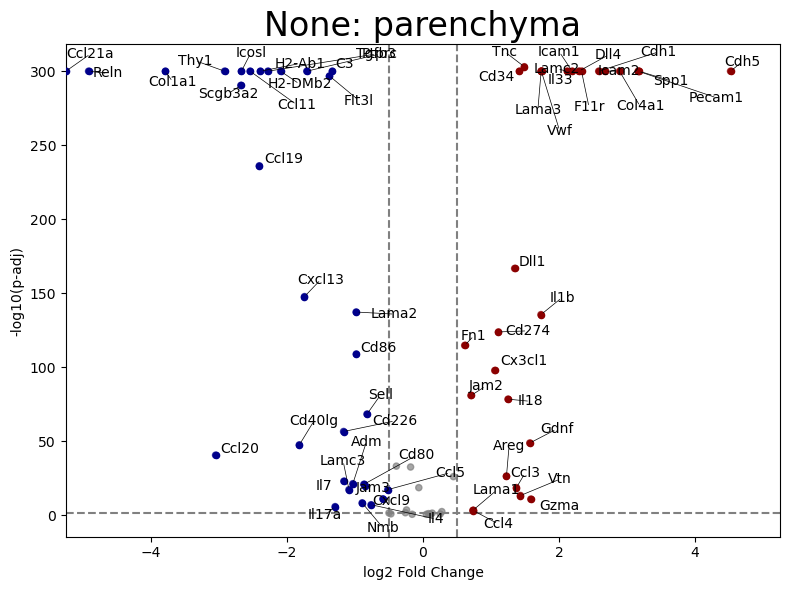

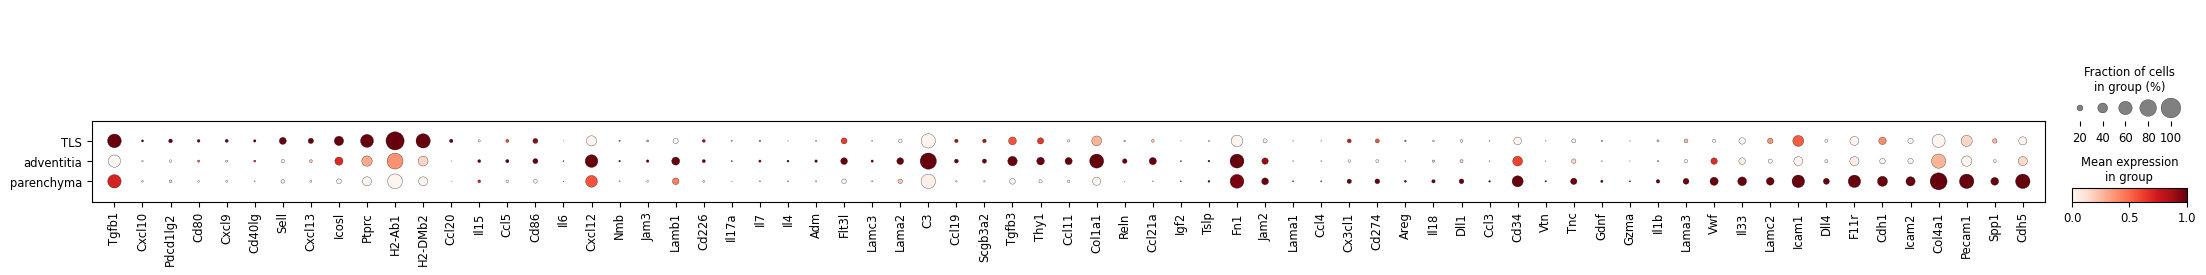

In [15]:
sample_label = 'HDM_day3'
zone_col = 'zone_consol'
zone_order=['TLS','adventitia', 'parenchyma'] 
    
adata_select = adata[adata.obs['sample_label']==sample_label, ligands_panel]
adata_select = adata_select[adata_select.obs[zone_col].isin(zone_order),:]
    
df_DEG_lig, df_DEG_lig_filt = run_zone_DE_analysis(
    adata=adata_select,
    celltype=None,
    # celltype_col = 'label_medium',
    zone_col = 'zone_consol',
    zone_order=['TLS','adventitia', 'parenchyma'], 
    reference_zone='rest',
    lfc_cutoff=0.5,
    pval_cutoff=0.05,
    expression_threshold = 0.01,
    dot_save_path =os.path.join(plot_out_dir, 'dotplot_lig_zone_de.pdf')
)

In [23]:
df_DEG_lig.head()

,names,logfoldchanges,pvals_adj,group
0,H2-Ab1,3.814358,0.000000e+00,TLS
1,H2-DMb2,4.470057,0.000000e+00,TLS
2,Ptprc,2.961898,0.000000e+00,TLS
3,Icosl,2.878886,0.000000e+00,TLS
4,Sell,2.439341,1.557266e-305,TLS


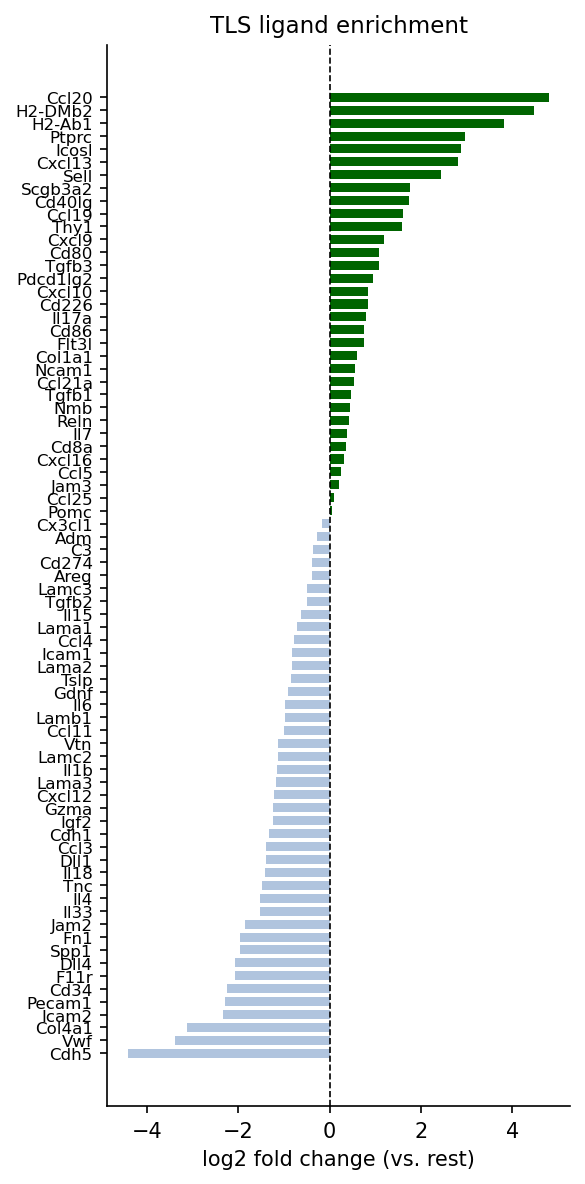

In [22]:
df_tls = (
    df_DEG_lig[df_DEG_lig['group'] == 'TLS']
    .sort_values('logfoldchanges', ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(4, len(df_tls) * 0.1 + 0.5), dpi=150)

colors = ['darkgreen' if v > 0 else 'lightsteelblue' for v in df_tls['logfoldchanges']]
ax.barh(df_tls['names'], df_tls['logfoldchanges'], color=colors, edgecolor='none', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

ax.set_xlabel('log2 fold change (vs. rest)', fontsize=10)
ax.set_title('TLS ligand enrichment', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

fig.tight_layout()
plt.savefig(os.path.join(plot_out_dir, 'HDM_day3_TLS_ligand_lfc_barplot.pdf'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## PD1 signaling

99


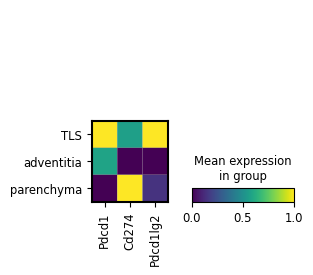

In [19]:
ligands_panel = df_lr[df_lr['ligand'].isin(adata.var.index)]['ligand'].unique().tolist()
print(len(ligands_panel))

sample_label = 'HDM_day3'
adata_select = adata[adata.obs['sample_label']==sample_label,:]
adata_select = adata_select[adata_select.obs['zone_consol'].isin(['TLS', 'adventitia', 'parenchyma']),:]
sc.pl.matrixplot(adata_select, var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2'],
                 groupby='zone_consol', standard_scale = 'var', swap_axes=False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_zone_PD1_matrixplot.pdf"),bbox_inches='tight', transparent=True)

{'mainplot_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

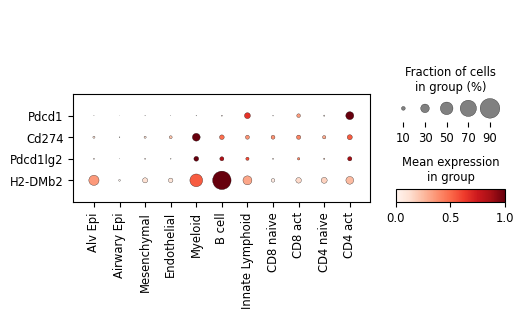

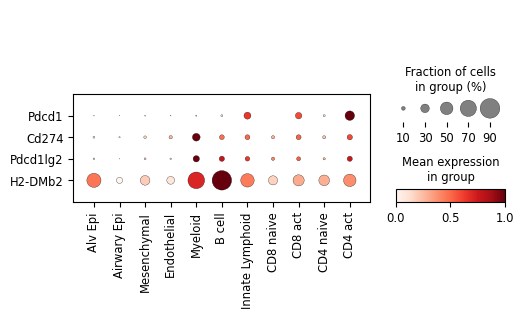

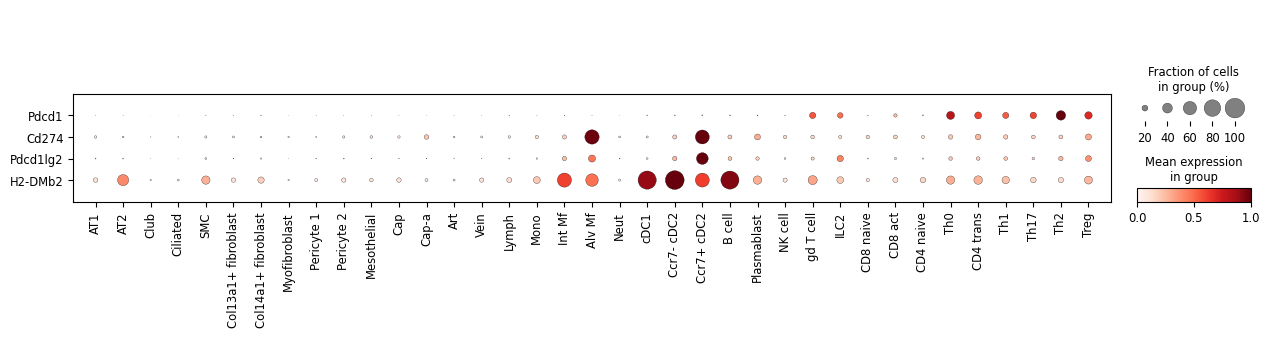

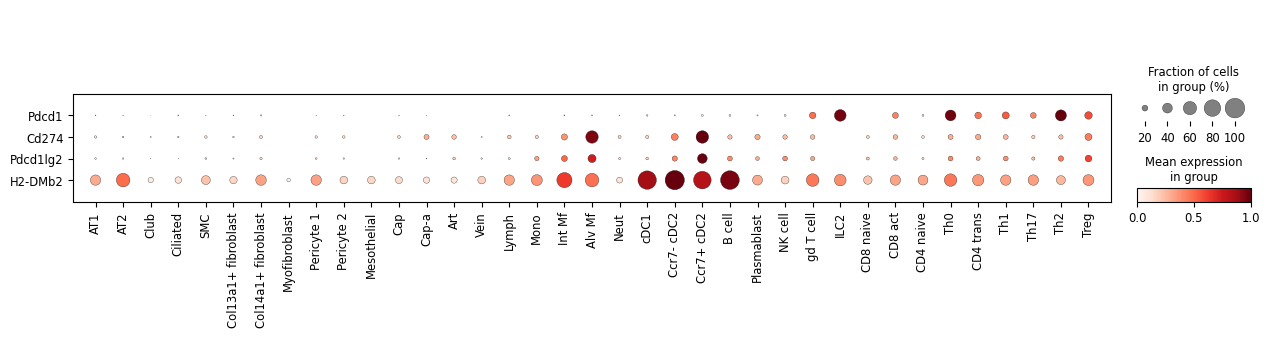

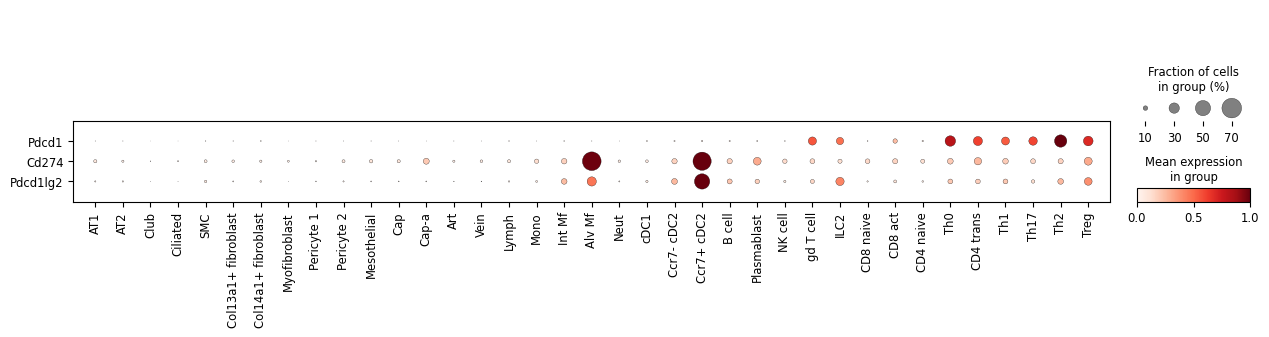

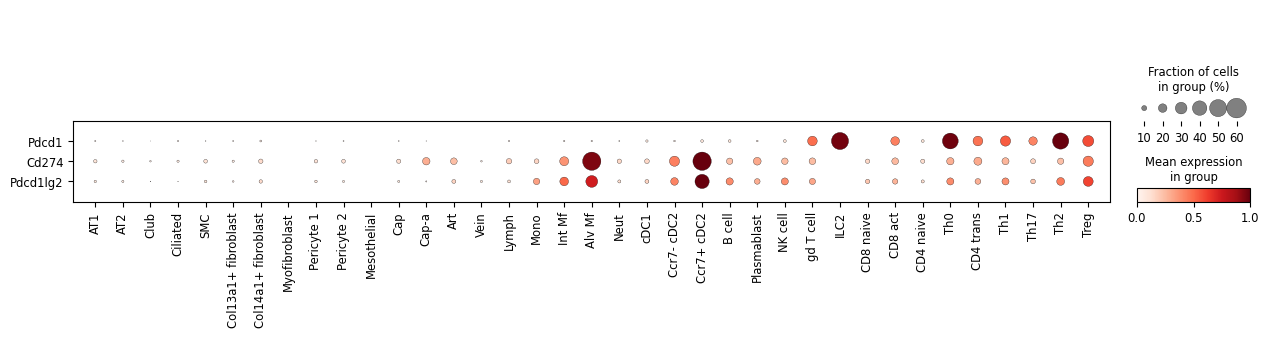

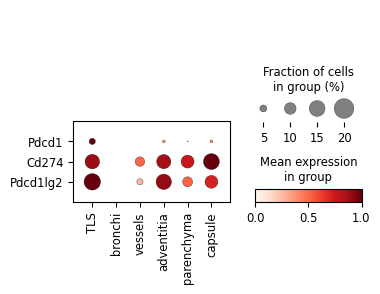

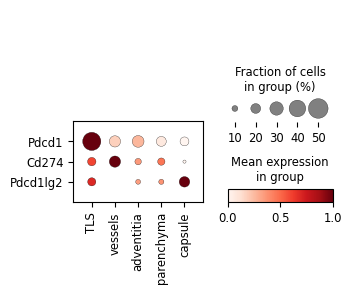

In [17]:
# What cell types express PD1 players
sc.pl.dotplot(adata, var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2', 'H2-DMb2'], groupby='label_medium', standard_scale = 'var', swap_axes=True, show=False)
sc.pl.dotplot(adata[adata.obs['zone_consol']=='TLS', :], var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2', 'H2-DMb2'], groupby='label_medium', standard_scale = 'var', swap_axes=True, show=False)

# What cell types express PD1 players - label fine
sc.pl.dotplot(adata, var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2', 'H2-DMb2'], groupby='label_fine', standard_scale = 'var', swap_axes=True, show=False)
sc.pl.dotplot(adata[adata.obs['zone_consol']=='TLS', :], var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2', 'H2-DMb2'], groupby='label_fine', standard_scale = 'var', swap_axes=True, show=False)

# What cell types express PD1 players - by zone
sc.pl.dotplot(adata, var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2'], groupby='label_fine', standard_scale = 'var', swap_axes=True, show=False)
plt.savefig(os.path.join(plot_out_dir, 'PD1_dotplot_allzones.pdf'), dpi=300, bbox_inches="tight")
sc.pl.dotplot(adata[adata.obs['zone_consol']=='TLS', :], var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2'], groupby='label_fine', standard_scale = 'var', swap_axes=True, show=False)
plt.savefig(os.path.join(plot_out_dir, 'PD1_dotplot_tls.pdf'), dpi=300, bbox_inches="tight")

# in specific cell types
sc.pl.dotplot(adata[adata.obs['label_fine']=='B cell', :], var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2'], groupby='zone_consol', standard_scale = 'var', swap_axes=True, show=False)
sc.pl.dotplot(adata[adata.obs['label_fine']=='Th0', :], var_names = ['Pdcd1', 'Cd274', 'Pdcd1lg2'], groupby='zone_consol', standard_scale = 'var', swap_axes=True, show=False)

## Investigation of Th0 in the parenchyma
- Do a DE test between TLS and parenchyma Th0
- Violin plot for markers associated with circulation or residency between TLS and parenchyma Th0
- Distance of Th0 to vessels (?)

HDM_day3


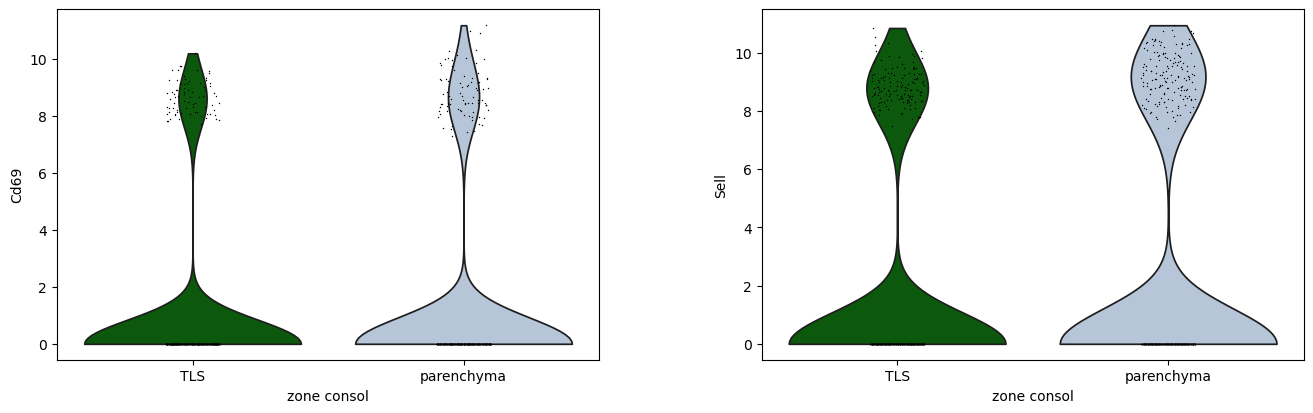

HDM_day30


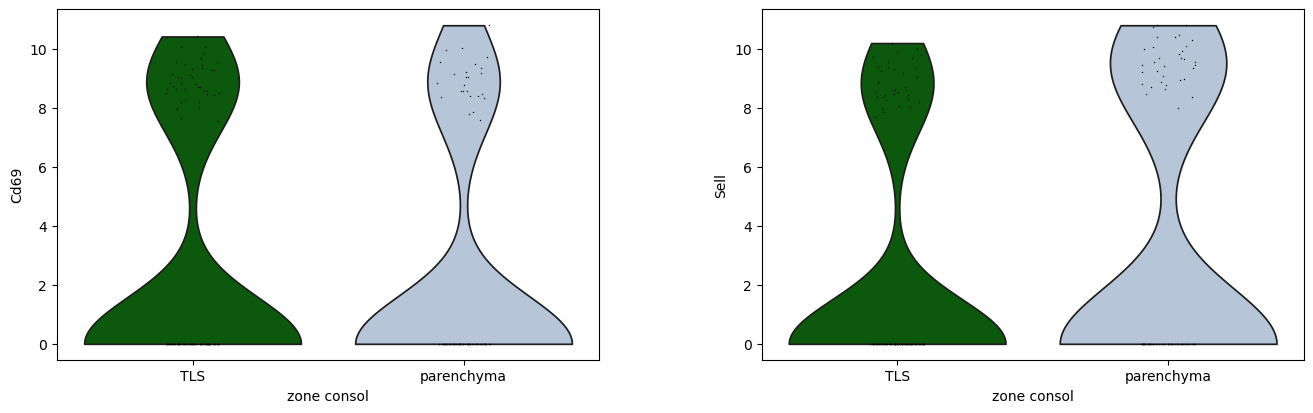

In [18]:
adata_th0 = adata[adata.obs['label_fine']=='Th0', :]

adata_th0_sub = adata_th0[adata_th0.obs['zone_consol'].isin(['TLS', 'parenchyma']), :]
for sample_label in ['HDM_day3', 'HDM_day30']:
    print(sample_label)
    sc.pl.violin(adata_th0_sub[adata_th0_sub.obs['sample_label']==sample_label, :], 
                 keys = ['Cd69', 'Sell'], groupby='zone_consol', palette = zone_consol_palette_mapped)

### DE between zones - within Th0

In [19]:
# CITE genes expressed in 5% of at least one subset
gene_df = pd.read_csv(os.path.join(BASE_OUTDIR, 'cell_labeling/ouputs_mouselung_hurskainen_ref_consolidate_labels_xenseg_HDM/cite_integration/cite_expressed_genes_by_annotation.csv'))
genes_cite_filt = gene_df['x'].tolist()

# Xenium genes expressed in 5% of at least one subset
genes_xen_filt = []
adata_cd4 = adata.copy()
for subset in adata_cd4.obs['label_fine'].unique().tolist():
    adata_cd4_subset = adata_cd4[adata_cd4.obs['label_fine'] == subset, :]
    adata_cd4_subset = filter_adata_expressed_in_n_cells(adata_cd4_subset, fraction=0.05)
    genes_xen_filt.extend(adata_cd4_subset.var.index.tolist())
genes_xen_filt = list(set(genes_xen_filt))

# take the intersection and use this list for heatmaps 
genes_cite_xen_filt = list(set(genes_cite_filt) & set(genes_xen_filt))

Subset shape: (1471, 184) for celltype: Th0
not subsetting by cell type
Unique DEGs before pval/lfc filter: 184
Unique DEGs after pval/lfc filter: 73


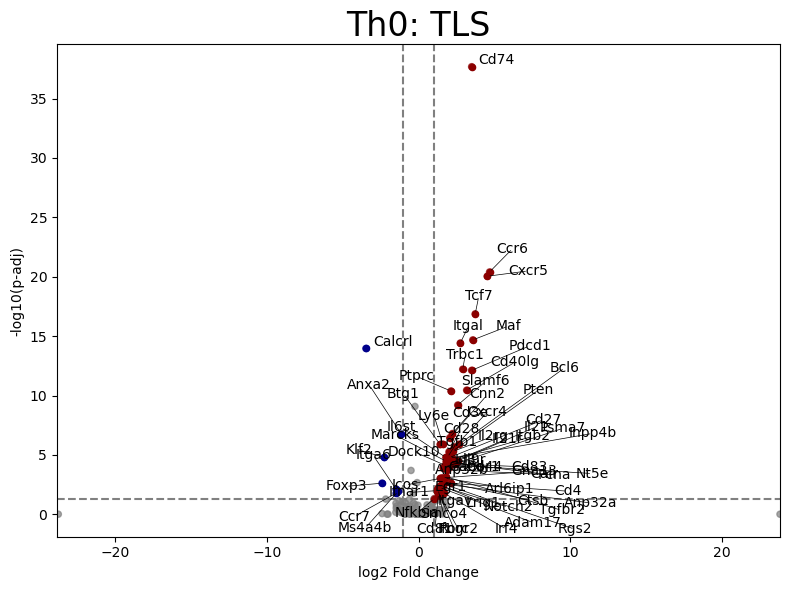

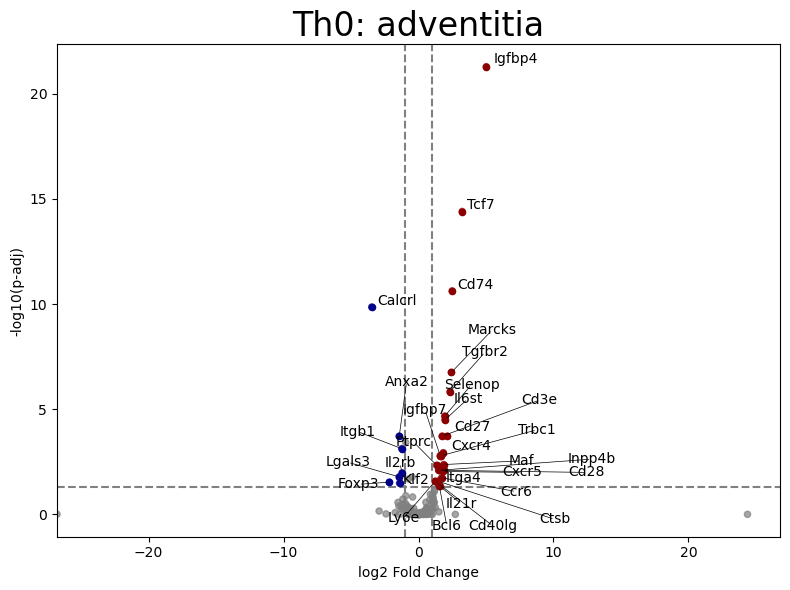

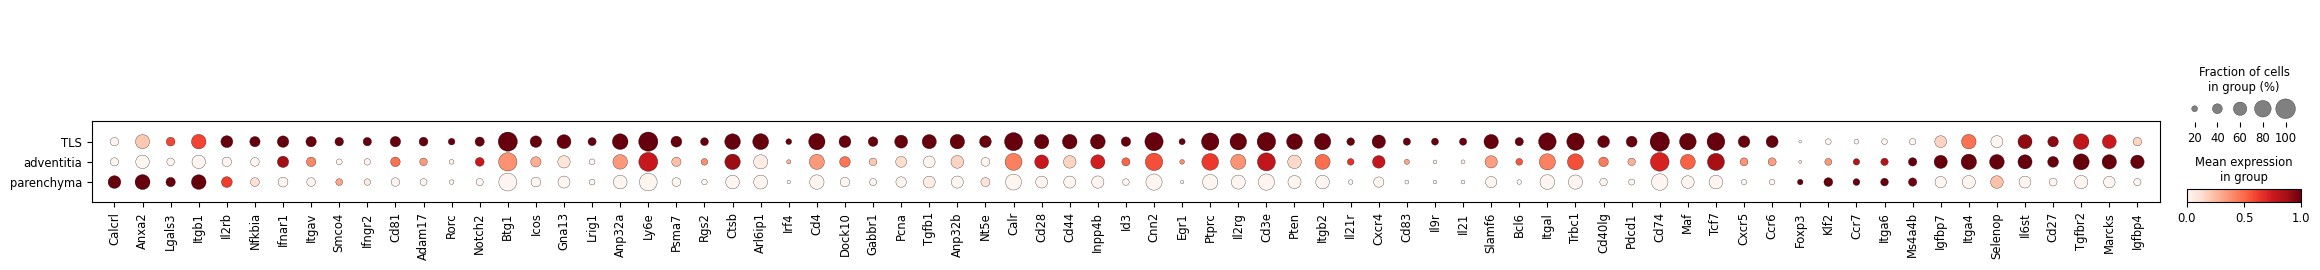

In [20]:
sample_label = 'HDM_day3'
celltype_col = 'label_fine'
celltype = 'Th0'

adata_select = adata[adata.obs['sample_label']==sample_label, genes_cite_xen_filt]
adata_select = adata_select[adata_select.obs[celltype_col]==celltype, :]

df_DEG_Th0, df_DEG_Th0_filt = run_zone_DE_analysis(
    adata=adata_select,
    celltype='Th0',
    celltype_col = 'label_fine',
    zone_col = 'zone_consol',
    zone_order=['TLS','adventitia', 'parenchyma'],
    reference_zone='parenchyma',
    lfc_cutoff=1,
    pval_cutoff=0.05,
    expression_threshold = None,
)

HDM_day3
HDM_day30


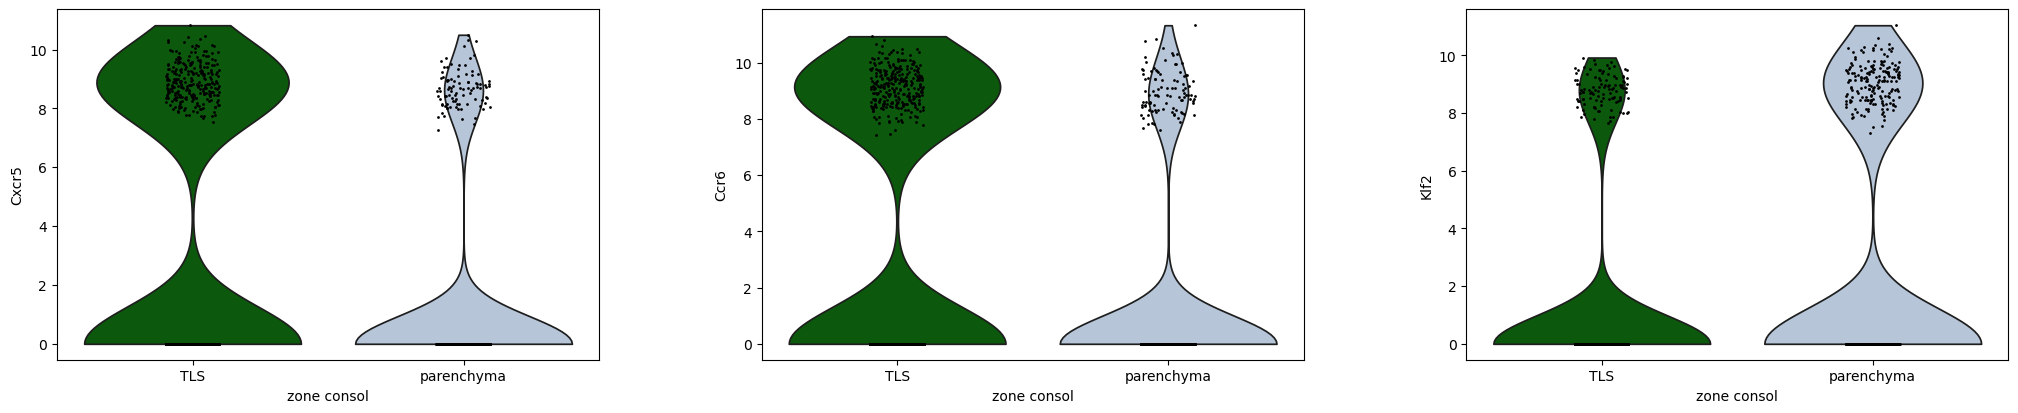

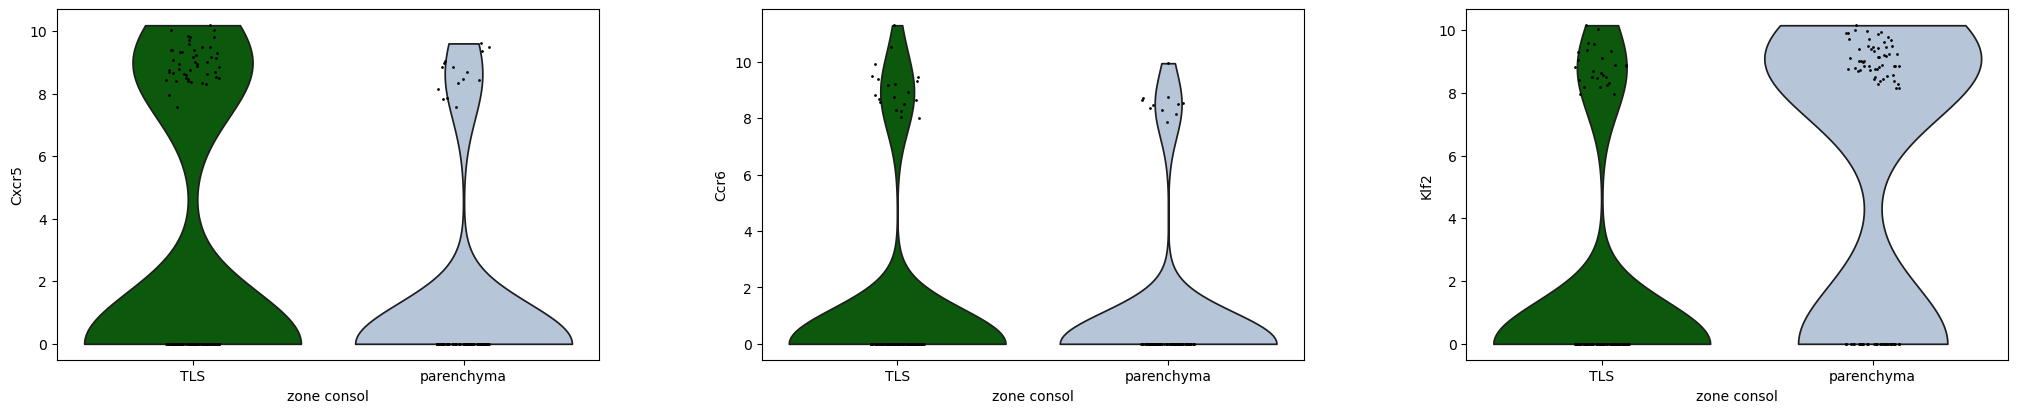

In [21]:
adata_th0 = adata[adata.obs['label_fine']=='Th0', :]
adata_th0_sub = adata_th0[adata_th0.obs['zone_consol'].isin(['TLS', 'parenchyma']), :]
for sample_label in ['HDM_day3', 'HDM_day30']:
    print(sample_label)
    sc.pl.violin(adata_th0_sub[adata_th0_sub.obs['sample_label']==sample_label, :], 
                 keys = ['Cxcr5', 'Ccr6', 'Klf2'], groupby='zone_consol', palette = zone_consol_palette_mapped, size=2, show=False)
    plt.savefig(os.path.join(plot_out_dir, f"{sample_label}_violin_cd4_tls_parenchyma.pdf"), dpi=300, bbox_inches="tight")

In [22]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active conda environment:  space2
